In [44]:
# Here in this notebook, we've plotted a histogram to have an idea of the observation point distribution for CVS and non-CVS
# We grouped data via objectId
# filter through pure unknown and catacly_V*
#heads down the numbers of unknowns and took all the CVS
#check code for 5 elements then fetch light curve for all chosen objects
#put a filter with only r band data
#extract statistical features and saved them
#import useful python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import light_curve as lc

In [2]:
#load main dataset
df=pd.read_parquet('new_masked_object.parquet')

In [3]:
#check dataset
df


,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF17aaafglk,22.733957,2,2.461074e+06,18.219936,1141,43.682294,0.073630,CataclyV*
1,ZTF18abavrhi,13.862530,2,2.461074e+06,16.578445,2212,244.787948,0.052932,CataclyV*
2,ZTF18acqxpid,-0.161225,2,2.461059e+06,18.902857,1094,120.643249,0.121745,CataclyV*
3,ZTF17aabsjcc,69.741185,2,2.461052e+06,17.685396,3032,67.679096,0.058235,CataclyV*
4,ZTF18abpprml,44.076774,2,2.461052e+06,19.825302,1235,91.110824,0.188079,CataclyV*
...,...,...,...,...,...,...,...,...,...
936921,ZTF18acignnq,10.637594,2,2.461084e+06,16.735125,843,298.666294,0.052518,Unknown
936922,ZTF21aageiie,-5.146635,1,2.461073e+06,15.013954,112,42.846437,0.064213,Unknown
936923,ZTF18aairqhf,16.401699,2,2.461073e+06,17.714146,3422,92.159086,0.076830,Unknown
936924,ZTF18acyxksn,-3.204930,2,2.461073e+06,15.386559,216,166.524802,0.048081,Unknown


In [4]:
#make two different arrays for histogram part
cv_df = df[df["finkclass"].str.contains("CataclyV*")]
unknown_df = df[df["finkclass"] == "Unknown"]

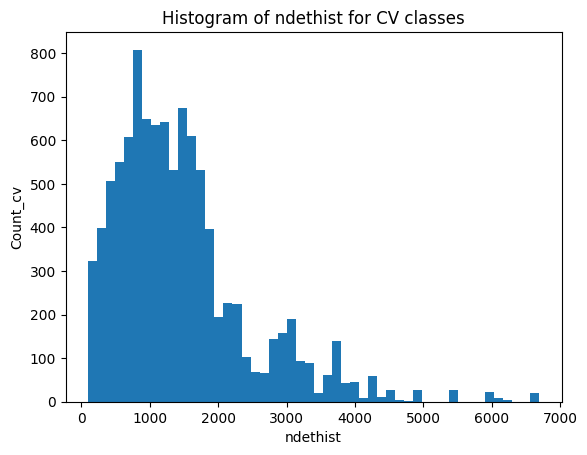

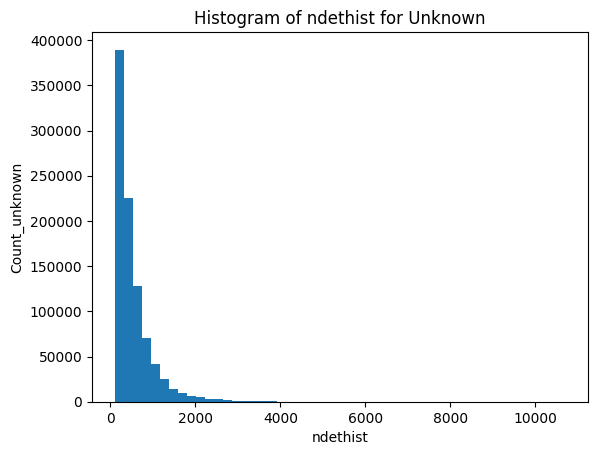

In [5]:
# CV classes histogram
#ndethist stands for number of observations points
plt.hist(cv_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for CV classes")
plt.xlabel("ndethist")
plt.ylabel("Count_cv")
plt.show()

# Unknown histogram
plt.hist(unknown_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for Unknown")
plt.xlabel("ndethist")
plt.ylabel("Count_unknown")
plt.show()

In [6]:
#count of element distribution
print(df['finkclass'].value_counts())
print("Total objects:", len(df))

finkclass
Unknown                 926983
CataclyV*                 9894
CataclyV*_Candidate         49
Blazar                       0
WhiteDwarf_Candidate         0
Name: count, dtype: int64
Total objects: 936926


In [7]:
#data grouping via objectId for having a dataframe
data = df.groupby("objectId", as_index=False).agg(list)

In [8]:
#shape
data.shape

(263543, 9)

In [9]:
#dataframe
data

,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF17aaaaaao,[45.430759],[2],[2461054.6163773],[18.84351348876953],[673],[63.9896447],[0.16620971262454987],[Unknown]
1,ZTF17aaaaabl,[51.4287671],[2],[2461059.6730787],[17.644813537597656],[2578],[69.9260651],[0.042603861540555954],[Unknown]
2,ZTF17aaaaaes,[47.3956061],[2],[2461053.8471759],[18.916994094848633],[1714],[77.5418002],[0.11988057941198349],[Unknown]
3,ZTF17aaaaafy,"[45.2503262, 45.2502987, 45.25031, 45.2502513,...","[2, 2, 2, 2, 2, 2, 2, 2, 2]","[2461075.7216782, 2461055.7841667, 2461074.690...","[19.56412124633789, 19.62184715270996, 19.3670...","[880, 858, 873, 869, 849, 872, 871, 863, 872]","[67.1171799, 67.1172413, 67.1172402, 67.117122...","[0.1536625623703003, 0.16926050186157227, 0.11...","[Unknown, Unknown, Unknown, Unknown, Unknown, ..."
4,ZTF17aaaaafz,"[45.4096531, 45.409699, 45.4096631, 45.409654,...","[1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, ...","[2461060.6384375, 2461051.8011921, 2461055.784...","[19.610416412353516, 18.52537727355957, 17.792...","[2950, 2926, 2936, 2957, 2963, 2965, 2962, 295...","[67.3091671, 67.3091481, 67.3091953, 67.309188...","[0.1247432753443718, 0.12439146637916565, 0.06...","[Unknown, Unknown, Unknown, Unknown, Unknown, ..."
...,...,...,...,...,...,...,...,...,...
263538,ZTF26aahnfbd,[15.5479036],[1],[2461095.7147569],[17.74433708190918],[816],[104.4409572],[0.11005722731351852],[Unknown]
263539,ZTF26aahnlws,[-5.9239914],[1],[2461095.7294907],[18.9563045501709],[139],[108.7912605],[0.1571178138256073],[Unknown]
263540,ZTF26aahnsph,[-19.3192024],[1],[2461095.7502315],[15.248769760131836],[108],[114.8402318],[0.08236127346754074],[Unknown]
263541,ZTF26aahoxfv,[-19.0463413],[2],[2461095.7915046],[20.121084213256836],[104],[139.4015478],[0.19747285544872284],[Unknown]


In [10]:
#count of element distribution wrt finkclass
print(data['finkclass'].value_counts())
print("Total objects:", len(data))

finkclass
[Unknown]                                                                                                                                                                                                                                                        127690
[Unknown, Unknown]                                                                                                                                                                                                                                                41826
[Unknown, Unknown, Unknown]                                                                                                                                                                                                                                       22134
[Unknown, Unknown, Unknown, Unknown]                                                                                                                                                                  

In [11]:
#check all unknown elements
unknown_df = data[data["finkclass"].apply(lambda x: all(v == "Unknown" for v in x))]

In [12]:
#count unknown objects
print("Pure Unknown objects:", len(unknown_df))

Pure Unknown objects: 262400


In [13]:
#check inputs with all cataclysemic variable data
cv_all = data[data["finkclass"].apply(lambda x: all(v in ["CataclyV*"] for v in x))]

In [14]:
#count cvs
print("CVs:", len(cv_all))

CVs: 984


In [15]:
#file making
unknown_sample = unknown_df.sample(n=1200, random_state=42)
# concatenation
final_df = pd.concat([unknown_sample, cv_all])
#shuffle 
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [16]:
#final heads
print(final_df.head())
print("Total objects:", len(final_df))

       objectId                                                dec  \
0  ZTF19adbqerg                            [55.2324081, 55.232558]   
1  ZTF18aadggvs  [30.388032, 30.3881523, 30.3881369, 30.3881536...   
2  ZTF20aceobuz                                       [17.5211556]   
3  ZTF18abcpvwv                                      [-11.9270944]   
4  ZTF19aapgrjj                         [-10.0944953, -10.0943075]   

                                                fid  \
0                                            [1, 1]   
1  [1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1]   
2                                               [2]   
3                                               [2]   
4                                            [1, 2]   

                                                  jd  \
0                 [2461055.6820833, 2461049.6965972]   
1  [2461053.806169, 2461080.7666667, 2461051.7353...   
2                                   [2461080.817662]   
3                       

In [17]:
#check if any repeated entries are here
print("Rows:", len(final_df))
print("Unique objects:", final_df["objectId"].nunique())

Rows: 2184
Unique objects: 2184


In [18]:
#saving final working dataset
final_df.to_parquet("my_dataset.parquet", index=False)

In [19]:
#heads
final_df

,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF19adbqerg,"[55.2324081, 55.232558]","[1, 1]","[2461055.6820833, 2461049.6965972]","[16.221145629882812, 16.102266311645508]","[321, 318]","[70.2277579, 70.2276149]","[0.07419487833976746, 0.06642571836709976]","[Unknown, Unknown]"
1,ZTF18aadggvs,"[30.388032, 30.3881523, 30.3881369, 30.3881536...","[1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1]","[2461053.806169, 2461080.7666667, 2461051.7353...","[19.29898452758789, 19.26337432861328, 19.1522...","[344, 359, 338, 354, 346, 353, 350, 363, 349, ...","[97.5022053, 97.5022323, 97.5022554, 97.502186...","[0.17835858464241028, 0.13391663134098053, 0.1...","[Unknown, Unknown, Unknown, Unknown, Unknown, ..."
2,ZTF20aceobuz,[17.5211556],[2],[2461080.817662],[20.06966781616211],[122],[135.5671437],[0.16899634897708893],[Unknown]
3,ZTF18abcpvwv,[-11.9270944],[2],[2461080.0610764],[17.784343719482422],[132],[271.1782561],[0.09518036991357803],[Unknown]
4,ZTF19aapgrjj,"[-10.0944953, -10.0943075]","[1, 2]","[2461076.0147338, 2461055.0651389]","[15.491485595703125, 15.572755813598633]","[400, 387]","[232.5547101, 232.554519]","[0.016479583457112312, 0.06561756134033203]","[Unknown, Unknown]"
...,...,...,...,...,...,...,...,...,...
2179,ZTF18aazxcdt,"[5.8457683, 5.845766]","[1, 1]","[2461061.0406713, 2461059.0605556]","[19.67622184753418, 19.409210205078125]","[461, 460]","[242.3861288, 242.3861326]","[0.1252940148115158, 0.1141638234257698]","[CataclyV*, CataclyV*]"
2180,ZTF19aaljlvm,[-7.1786852],[1],[2461065.7928241],[16.012645721435547],[137],[119.7757041],[0.06110411882400513],[Unknown]
2181,ZTF25aaqweno,"[24.3192108, 24.3191844, 24.3191595, 24.319134...","[2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2]","[2461061.6618056, 2461072.6572106, 2461074.715...","[14.041205406188965, 14.169975280761719, 15.74...","[198, 203, 205, 207, 195, 200, 201, 199, 193, ...","[19.1349591, 19.1349842, 19.1349313, 19.134973...","[0.03229690343141556, 0.02173655666410923, 0.0...","[Unknown, Unknown, Unknown, Unknown, Unknown, ..."
2182,ZTF17aabcvez,"[16.8114471, 16.811495, 16.8113787, 16.8114333...","[1, 1, 1, 1, 1, 1, 1]","[2461094.6876968, 2461072.6277546, 2461074.648...","[18.879688262939453, 19.01930046081543, 18.962...","[733, 726, 727, 723, 729, 729, 722]","[74.1855722, 74.18548, 74.1855259, 74.185607, ...","[0.153757706284523, 0.19826318323612213, 0.115...","[CataclyV*, CataclyV*, CataclyV*, CataclyV*, C..."


In [20]:
#cross check again
#print unique
print("Unique objects:", final_df["objectId"].nunique())

Unique objects: 2184


In [21]:
#lightcurve extraction
# Load dataset (only first 5 rows for testing)
df_test = pd.read_parquet("my_dataset.parquet").head(5)
print("Total rows:", len(df_test))
# Group by objectId
#df_test = df_test0.groupby("objectId", as_index=False).agg(list)
#print ('total number of rows',len(df_test),'\n\n')
#groups = df_test.groupby("objectId")
#null array
all_rows = []
#r_count = 0   # counter for r-band detections
## Process objects
#i for count
for i in range(len(df_test)):
    object_id = df_test["objectId"].iloc[i]  #tracking objectIds
    print(f"Processing {i+1}: {object_id}")
#taking mean ra,dec to take all of them with the 1.2 arcsec circle
    ra = np.mean(df_test["ra"].iloc[i])
    dec = np.mean(df_test["dec"].iloc[i])
#finkclass as first entry,not in array form
    finkclass = df_test["finkclass"].iloc[i][0]
    try:
        # Query SNAD
        
        url = "https://db.ztf.snad.space/api/v3/data/latest/circle/full/json"   #web

        params = {
            "ra": ra,
            "dec": dec,
            "radius_arcsec": 1.2   #small circle
        }

        r = requests.get(url, params=params)
        r.raise_for_status()

        data = r.json()

        if len(data) == 0:         #if no data returned
            print("no data found..")
            continue
             # Extract light curve
       
        for name in data:     #loop over objects

            lc = data[name].get("lc", []) #"lc" key,a list of data points for the current name, defaulting to an empty list [] if it doesn't exis
            filt = data[name].get("meta", {}).get("filter", None) #navigates nested "meta" dictionary to retrieve the "filter" value, defaulting to None if meta or filter is missing.

            for point in lc: #loop over biggie lightcurve entries

                all_rows.append({       #adding inputs over objectids
                    "objectId": object_id,
                    "finkclass": finkclass,
                    "oid": name,
                    "mjd": point.get("mjd"),
                    "mag": point.get("mag"),
                    "magerr": point.get("magerr"),
                    "filter": filt
                })

    except Exception as e:
        print("Error fetching", object_id, e)  

    time.sleep(0.5)
    # Create dataframe

final_df = pd.DataFrame(all_rows)

print("Total photometry rows collected:", len(final_df))


# group
grouped_df = final_df.groupby("objectId").agg({   #grouping them
    "finkclass": "first",
    "oid": "first",
    "filter": list,
    "mjd": list,
    "mag": list,
    "magerr": list
}).reset_index()

print("Objects after grouping:", len(grouped_df))

# Save output

grouped_df.to_parquet("snad_lightcurves_grouped_2.parquet")

print("Saved file: snad_lightcurves_grouped_1.parquet")

# Display result


print(grouped_df.head())



Total rows: 5
Processing 1: ZTF19adbqerg
Processing 2: ZTF18aadggvs
Processing 3: ZTF20aceobuz
Processing 4: ZTF18abcpvwv
Processing 5: ZTF19aapgrjj
Total photometry rows collected: 4544
Objects after grouping: 5
Saved file: snad_lightcurves_grouped_1.parquet
       objectId finkclass              oid  \
0  ZTF18aadggvs   Unknown  660101400014853   
1  ZTF18abcpvwv   Unknown  383104100004703   
2  ZTF19aapgrjj   Unknown  377306100002112   
3  ZTF19adbqerg   Unknown  779111400012846   
4  ZTF20aceobuz   Unknown  569108400002074   

                                              filter  \
0  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
1  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
2  [zi, zi, zi, zi, zi, zi, zi, zi, zi, zi, zi, z...   
3  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
4  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   

                                                 mjd  \
0  [58204.2364, 58205.21471, 58206.22974, 58207.1...   
1  [58205.4730

In [22]:
#keys
print(grouped_df.columns)

Index(['objectId', 'finkclass', 'oid', 'filter', 'mjd', 'mag', 'magerr'], dtype='object')


In [23]:
#rband detections only
#null arrays
mjd_r = []
mag_r = []
magerr_r = []
filter_r = []
#looping over each objects
for i in range(len(grouped_df)):
    #putting a mask with 'zr' obs only
    mask = np.array(grouped_df.iloc[i]["filter"]) == "zr"
    #'zr' obs over lightcurve data
    mjd = np.array(grouped_df.iloc[i]["mjd"])[mask]
    mag = np.array(grouped_df.iloc[i]["mag"])[mask]
    magerr = np.array(grouped_df.iloc[i]["magerr"])[mask]
    filt = np.array(grouped_df.iloc[i]["filter"])[mask]
    #create data frame
    mjd_r.append(mjd)
    mag_r.append(mag)
    magerr_r.append(magerr)
    filter_r.append(filt)

In [24]:
#adding r_band columns to my original lightcurve data
grouped_df["mjd_r"] = mjd_r
grouped_df["mag_r"] = mag_r
grouped_df["magerr_r"] = magerr_r
grouped_df["filter_r"]=filter_r

In [25]:
#checking if worked
print(grouped_df[["mjd_r","mag_r","magerr_r",]].head())

                                               mjd_r  \
0  [58216.16465, 58219.15297, 58219.16453, 58219....   
1  [58218.48496, 58218.50686, 58246.44322, 58247....   
2                                                 []   
3  [58216.16539, 58217.1498, 58218.20432, 58219.1...   
4  [58217.19903, 58217.22288, 58227.16448, 58243....   

                                               mag_r  \
0  [16.52742, 16.346462, 16.324669, 16.350372, 16...   
1  [15.64091, 15.659638, 15.658449, 15.653989, 15...   
2                                                 []   
3  [12.576925, 12.610568, 12.615757, 12.637891, 1...   
4  [19.195745, 19.259373, 19.243904, 19.217043, 1...   

                                            magerr_r  
0  [0.015759436, 0.01483697, 0.014735225, 0.01485...  
1  [0.018501366, 0.018548725, 0.01854569, 0.01853...  
2                                                 []  
3  [0.009206315, 0.00921207, 0.009212964, 0.00921...  
4  [0.08102398, 0.08512688, 0.08411169, 0.0823759..

In [26]:
#dataframe version
grouped_df

,objectId,finkclass,oid,filter,mjd,mag,magerr,mjd_r,mag_r,magerr_r,filter_r
0,ZTF18aadggvs,Unknown,660101400014853,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.2364, 58205.21471, 58206.22974, 58207.1...","[17.341908, 17.101746, 17.2902, 17.109747, 17....","[0.020001402, 0.018042646, 0.019542705, 0.0181...","[58216.16465, 58219.15297, 58219.16453, 58219....","[16.52742, 16.346462, 16.324669, 16.350372, 16...","[0.015759436, 0.01483697, 0.014735225, 0.01485...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
1,ZTF18abcpvwv,Unknown,383104100004703,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58205.47304, 58205.52771, 58206.44781, 58207....","[18.317936, 18.307064, 18.303993, 18.291214, 1...","[0.049118817, 0.048874255, 0.04880557, 0.04852...","[58218.48496, 58218.50686, 58246.44322, 58247....","[15.64091, 15.659638, 15.658449, 15.653989, 15...","[0.018501366, 0.018548725, 0.01854569, 0.01853...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2,ZTF19aapgrjj,Unknown,377306100002112,"[zi, zi, zi, zi, zi, zi, zi, zi, zi, zi, zi, z...","[58246.27937, 58261.27771, 58274.37453, 58280....","[12.453964, 12.460151, 12.44559, 12.446257, 12...","[0.026660781, 0.026634516, 0.026696347, 0.0266...",[],[],[],[]
3,ZTF19adbqerg,Unknown,779111400012846,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58210.20454, 58216.18958, 58235.15742, 58307....","[13.465949, 13.341305, 13.451083, 13.442845, 1...","[0.013457049, 0.013463488, 0.013457644, 0.0134...","[58216.16539, 58217.1498, 58218.20432, 58219.1...","[12.576925, 12.610568, 12.615757, 12.637891, 1...","[0.009206315, 0.00921207, 0.009212964, 0.00921...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
4,ZTF20aceobuz,Unknown,569108400002074,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58202.26824, 58206.19413, 58206.25781, 58233....","[19.439465, 19.5679, 19.428478, 19.887947, 19....","[0.08074123, 0.08854991, 0.08010248, 0.1106842...","[58217.19903, 58217.22288, 58227.16448, 58243....","[19.195745, 19.259373, 19.243904, 19.217043, 1...","[0.08102398, 0.08512688, 0.08411169, 0.0823759...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."


In [27]:
#checking how many r_band obs were there: number should be always less that original number of obs
total_r_obs = sum(len(x) for x in mjd_r)
print("Total photometry for r-band observations:", total_r_obs)

Total photometry for r-band observations: 2947


In [28]:
#collected observation 4455, for r band 2947, of course, less in number
#keep only r_band data
grouped_df = grouped_df.drop(columns=["mjd","mag","magerr","filter"])

In [29]:
#save in a file
grouped_df.to_parquet("snad_lightcurves_grouped_2_r_band.parquet")


In [30]:
#outside of this notebook I ran code to fetch lightcurves for my 2185 objects in "my_dataset.parquet" file
#output given as:Total photometry rows collected: 2948750
#Objects after grouping: 2092
#Saved file: snad_lightcurves_grouped.parquet
#loading the new file
df_lc=pd.read_parquet("snad_lightcurves_grouped.parquet")

In [31]:
#checking its format
df_lc

,objectId,finkclass,oid,filter,mjd,mag,magerr
0,ZTF17aaaadkj,CataclyV*,743102100005228,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.12504, 58204.16156, 58206.12473, 58206....","[18.212118, 18.1215, 18.324465, 18.40276, 18.2...","[0.033463914, 0.03208954, 0.035320017, 0.03672..."
1,ZTF17aaaagyq,CataclyV*,743111100012626,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58216.18987, 58324.443, 58325.44341, 58329.46...","[17.597532, 17.123909, 17.184433, 17.053848, 1...","[0.02315536, 0.018985413, 0.019429546, 0.01849..."
2,ZTF17aaaaqna,Unknown,776105200010442,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58302.44464, 58304.4688, 58305.46594, 58312.4...","[15.350836, 15.279475, 15.751375, 15.216327, 1...","[0.016644616, 0.016571306, 0.017174384, 0.0165..."
3,ZTF17aaaarmr,CataclyV*,703106200000801,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58206.12602, 58206.14519, 58207.24488, 58210....","[16.625607, 16.585968, 16.463081, 16.486929, 1...","[0.020074423, 0.01985601, 0.01924174, 0.019353..."
4,ZTF17aaaazob,CataclyV*,651109400004459,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58275.46801, 58280.44675, 58283.44612, 58286....","[18.443819, 17.906633, 17.686993, 17.911257, 1...","[0.04150144, 0.028805345, 0.025153672, 0.02889..."
...,...,...,...,...,...,...,...
2087,ZTF26aaajqnu,CataclyV*,314101100011723,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58202.25777, 58205.23202, 58205.26256, 58229....","[16.805225, 16.637238, 16.80944, 16.724371, 17...","[0.017858543, 0.016702052, 0.017890256, 0.0172..."
2088,ZTF26aaaombw,Unknown,413103100004106,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.20115, 58204.22551, 58207.23742, 58207....","[16.645649, 16.641018, 16.519295, 16.538471, 1...","[0.015509142, 0.015487184, 0.014946876, 0.0150..."
2089,ZTF26aabsgfq,Unknown,481103400002571,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58203.38033, 58203.42071, 58206.38442, 58206....","[14.525244, 14.508674, 14.5277605, 14.521779, ...","[0.015527179, 0.015529649, 0.015526819, 0.0155..."
2090,ZTF26aaewgqp,Unknown,487108200006414,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58205.50942, 58205.52889, 58206.48772, 58207....","[15.570269, 15.564646, 15.550962, 15.529509, 1...","[0.022544837, 0.022532966, 0.022504255, 0.0224..."


In [32]:
#loping over rband detections only
#introducing null array
mjd_r = []
mag_r = []
magerr_r = []
filter_r = []
#count objects
for i in range(len(df_lc)):
    #putting mask of 'zr'
    mask = np.array(df_lc.iloc[i]["filter"]) == "zr"
    #putting mask over lc data
    mjd = np.array(df_lc.iloc[i]["mjd"])[mask]
    mag = np.array(df_lc.iloc[i]["mag"])[mask]
    magerr = np.array(df_lc.iloc[i]["magerr"])[mask]
    filt = np.array(df_lc.iloc[i]["filter"])[mask]
    #saving them
    mjd_r.append(mjd)
    mag_r.append(mag)
    magerr_r.append(magerr)
    filter_r.append(filt)

In [33]:
#adding column to my files
df_lc["mjd_r"] = mjd_r
df_lc["mag_r"] = mag_r
df_lc["magerr_r"] = magerr_r
df_lc["filter_r"]=filter_r

In [34]:
#runcheck
print(df_lc[["mjd_r","mag_r","magerr_r",]].head())

                                               mjd_r  \
0  [58216.13022, 58218.20371, 58219.16895, 58219....   
1  [58216.13019, 58218.20368, 58219.16893, 58219....   
2  [58278.47674, 58281.47627, 58283.46774, 58287....   
3  [58217.15044, 58219.1697, 58219.18939, 58231.1...   
4  [58283.46681, 58289.47003, 58297.42487, 58300....   

                                               mag_r  \
0  [17.412457, 17.338797, 17.176018, 17.167013, 1...   
1  [16.7305, 17.1317, 17.023548, 16.959763, 17.07...   
2  [14.294525, 14.2611685, 14.537104, 14.611805, ...   
3  [16.110184, 16.18475, 16.07745, 16.234774, 16....   
4  [17.644127, 17.994934, 17.403929, 18.084965, 1...   

                                            magerr_r  
0  [0.019831764, 0.019199144, 0.017942382, 0.0178...  
1  [0.014744257, 0.017051972, 0.016347088, 0.0159...  
2  [0.012580482, 0.012576667, 0.012624708, 0.0126...  
3  [0.015174726, 0.015401674, 0.015081054, 0.0155...  
4  [0.023059644, 0.02872228, 0.02016197, 0.030504..

In [35]:
#dataframe format
df_lc

,objectId,finkclass,oid,filter,mjd,mag,magerr,mjd_r,mag_r,magerr_r,filter_r
0,ZTF17aaaadkj,CataclyV*,743102100005228,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.12504, 58204.16156, 58206.12473, 58206....","[18.212118, 18.1215, 18.324465, 18.40276, 18.2...","[0.033463914, 0.03208954, 0.035320017, 0.03672...","[58216.13022, 58218.20371, 58219.16895, 58219....","[17.412457, 17.338797, 17.176018, 17.167013, 1...","[0.019831764, 0.019199144, 0.017942382, 0.0178...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
1,ZTF17aaaagyq,CataclyV*,743111100012626,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58216.18987, 58324.443, 58325.44341, 58329.46...","[17.597532, 17.123909, 17.184433, 17.053848, 1...","[0.02315536, 0.018985413, 0.019429546, 0.01849...","[58216.13019, 58218.20368, 58219.16893, 58219....","[16.7305, 17.1317, 17.023548, 16.959763, 17.07...","[0.014744257, 0.017051972, 0.016347088, 0.0159...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2,ZTF17aaaaqna,Unknown,776105200010442,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58302.44464, 58304.4688, 58305.46594, 58312.4...","[15.350836, 15.279475, 15.751375, 15.216327, 1...","[0.016644616, 0.016571306, 0.017174384, 0.0165...","[58278.47674, 58281.47627, 58283.46774, 58287....","[14.294525, 14.2611685, 14.537104, 14.611805, ...","[0.012580482, 0.012576667, 0.012624708, 0.0126...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
3,ZTF17aaaarmr,CataclyV*,703106200000801,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58206.12602, 58206.14519, 58207.24488, 58210....","[16.625607, 16.585968, 16.463081, 16.486929, 1...","[0.020074423, 0.01985601, 0.01924174, 0.019353...","[58217.15044, 58219.1697, 58219.18939, 58231.1...","[16.110184, 16.18475, 16.07745, 16.234774, 16....","[0.015174726, 0.015401674, 0.015081054, 0.0155...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
4,ZTF17aaaazob,CataclyV*,651109400004459,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58275.46801, 58280.44675, 58283.44612, 58286....","[18.443819, 17.906633, 17.686993, 17.911257, 1...","[0.04150144, 0.028805345, 0.025153672, 0.02889...","[58283.46681, 58289.47003, 58297.42487, 58300....","[17.644127, 17.994934, 17.403929, 18.084965, 1...","[0.023059644, 0.02872228, 0.02016197, 0.030504...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
...,...,...,...,...,...,...,...,...,...,...,...
2087,ZTF26aaajqnu,CataclyV*,314101100011723,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58202.25777, 58205.23202, 58205.26256, 58229....","[16.805225, 16.637238, 16.80944, 16.724371, 17...","[0.017858543, 0.016702052, 0.017890256, 0.0172...","[58218.19763, 58218.22603, 58226.1396, 58226.1...","[16.501411, 16.82343, 16.635225, 16.65099, 16....","[0.014929691, 0.017087083, 0.01573768, 0.01584...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2088,ZTF26aaaombw,Unknown,413103100004106,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58204.20115, 58204.22551, 58207.23742, 58207....","[16.645649, 16.641018, 16.519295, 16.538471, 1...","[0.015509142, 0.015487184, 0.014946876, 0.0150...","[58218.18849, 58218.19991, 58223.14537, 58223....","[15.509172, 15.524018, 15.55056, 15.526928, 15...","[0.010882512, 0.010905461, 0.010947581, 0.0109...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2089,ZTF26aabsgfq,Unknown,481103400002571,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58203.38033, 58203.42071, 58206.38442, 58206....","[14.525244, 14.508674, 14.5277605, 14.521779, ...","[0.015527179, 0.015529649, 0.015526819, 0.0155...","[58198.4209, 58216.38505, 58216.41105, 58218.4...","[13.994027, 13.9896345, 13.987596, 13.996452, ...","[0.0107431095, 0.010741732, 0.010741096, 0.010...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2090,ZTF26aaewgqp,Unknown,487108200006414,"[zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...","[58205.50942, 58205.52889, 58206.48772, 58207....","[15.570269, 15.564646, 15.550962, 15.529509, 1...","[0.022544837, 0.02

In [36]:
#keeping track of observations with and without r band mask
#lightcurves request collected:Total photometry rows collected: 2948750
total_r_obs = sum(len(x) for x in mjd_r)
print("Total photometry for r-band observations:", total_r_obs)

Total photometry for r-band observations: 1736356


In [37]:
#collected observation 4455, for r band 2947, of course, less in number
#keep only r_band data
df_lc = df_lc.drop(columns=["mjd","mag","magerr","filter"])

In [38]:
df_lc

,objectId,finkclass,oid,mjd_r,mag_r,magerr_r,filter_r
0,ZTF17aaaadkj,CataclyV*,743102100005228,"[58216.13022, 58218.20371, 58219.16895, 58219....","[17.412457, 17.338797, 17.176018, 17.167013, 1...","[0.019831764, 0.019199144, 0.017942382, 0.0178...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
1,ZTF17aaaagyq,CataclyV*,743111100012626,"[58216.13019, 58218.20368, 58219.16893, 58219....","[16.7305, 17.1317, 17.023548, 16.959763, 17.07...","[0.014744257, 0.017051972, 0.016347088, 0.0159...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2,ZTF17aaaaqna,Unknown,776105200010442,"[58278.47674, 58281.47627, 58283.46774, 58287....","[14.294525, 14.2611685, 14.537104, 14.611805, ...","[0.012580482, 0.012576667, 0.012624708, 0.0126...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
3,ZTF17aaaarmr,CataclyV*,703106200000801,"[58217.15044, 58219.1697, 58219.18939, 58231.1...","[16.110184, 16.18475, 16.07745, 16.234774, 16....","[0.015174726, 0.015401674, 0.015081054, 0.0155...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
4,ZTF17aaaazob,CataclyV*,651109400004459,"[58283.46681, 58289.47003, 58297.42487, 58300....","[17.644127, 17.994934, 17.403929, 18.084965, 1...","[0.023059644, 0.02872228, 0.02016197, 0.030504...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
...,...,...,...,...,...,...,...
2087,ZTF26aaajqnu,CataclyV*,314101100011723,"[58218.19763, 58218.22603, 58226.1396, 58226.1...","[16.501411, 16.82343, 16.635225, 16.65099, 16....","[0.014929691, 0.017087083, 0.01573768, 0.01584...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2088,ZTF26aaaombw,Unknown,413103100004106,"[58218.18849, 58218.19991, 58223.14537, 58223....","[15.509172, 15.524018, 15.55056, 15.526928, 15...","[0.010882512, 0.010905461, 0.010947581, 0.0109...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2089,ZTF26aabsgfq,Unknown,481103400002571,"[58198.4209, 58216.38505, 58216.41105, 58218.4...","[13.994027, 13.9896345, 13.987596, 13.996452, ...","[0.0107431095, 0.010741732, 0.010741096, 0.010...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."
2090,ZTF26aaewgqp,Unknown,487108200006414,"[58216.50843, 58217.48555, 58217.50679, 58218....","[14.528611, 14.573394, 14.575156, 14.5598955, ...","[0.016475614, 0.016494438, 0.01649521, 0.01648...","[zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, zr, z..."


In [39]:
#creating big lightcuve data
df_lc.to_parquet("snad_lightcurves_grouped_r_band.parquet")


In [40]:
import light_curve as lc
#statistical feature extraction
# Define feature extractor
extractor = lc.Extractor(
    lc.Mean(),
    lc.WeightedMean(),
    lc.StandardDeviation(),
    lc.Median(),
    lc.Amplitude(),
    lc.BeyondNStd(nstd=1),
    lc.Cusum(),
    lc.InterPercentileRange(0.10),
    lc.Kurtosis(),
    lc.LinearTrend(),
    lc.LinearFit(),
    lc.MagnitudePercentageRatio(0.4, 0.05),
    lc.MagnitudePercentageRatio(0.2, 0.1),
    lc.MaximumSlope(),
    lc.MedianAbsoluteDeviation(),
    lc.MedianBufferRangePercentage(0.10),
    lc.PercentAmplitude(),
    lc.MeanVariance(),
    lc.AndersonDarlingNormal(),
    lc.ReducedChi2(),
    lc.Skew(),
    lc.StetsonK()
)
# Feature extraction
results = []

In [41]:
for _, row in df_lc.iterrows():

    try:
        t = np.array(row["mjd_r"])
        m = np.array(row["mag_r"])
        err = np.array(row["magerr_r"])

        feats = extractor(t, m, err, sorted=True, check=False)

        results.append(
            [row["objectId"], row["finkclass"]] + list(feats)
        )

    except Exception as e:
        print(f"Skipping {row['objectId']} due to error: {e}")

# Create dataframe
features_df = pd.DataFrame(
    results,
    columns=["objectId", "finkclass"] + extractor.names
)

# Save feature space
features_df.to_parquet("my_feature_space.parquet", index=False)

print("Feature extraction complete!")
print("Saved to: new_feature_space.parquet")
print("Shape:", features_df.shape)

Skipping ZTF17aaannua due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF17aaaojvc due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18aabfgwe due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18aabgvwv due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abahibj due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abgtzzh due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abjiitj due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abjpdyc due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abktleu due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abmsmez due to error: time-series' length 0 is sma

In [42]:
#count of element distribution wrt finkclass
print(features_df['finkclass'].value_counts())
#print("Total objects:", len(data))

finkclass
Unknown      1081
CataclyV*     975
Name: count, dtype: int64


In [43]:
features_df[features_df["finkclass"].str.contains("CataclyV*", na=False)]["finkclass"].value_counts()

finkclass
CataclyV*    975
Name: count, dtype: int64